# 01 — Dataset Audit

**Project:** Spatio-temporal wildfire activity prediction over Sumatra and Kalimantan  
**Purpose:** Audit the raw FIRMS fire-detection data before spatial binning and feature engineering.

This notebook is designed as a **data-quality and coverage audit**, not as a modeling notebook.

### Audit objectives

1. Verify the raw FIRMS directory structure for **Kalimantan and Sumatra**.
2. Check file counts and filename/date coverage.
3. Inspect the schema of representative non-empty files.
4. Load all FIRMS files and validate:
   - timestamp parsing,
   - latitude/longitude,
   - FRP,
   - missing values,
   - exact duplicates,
   - duplicate detection coordinates/timestamps,
   - date coverage.
5. Summarize fire detections by region and date.
6. Produce basic visual diagnostics.
7. Save reusable audit outputs to `data/intermediate/`.

> **Important:** A FIRMS detection represents an observed satellite fire/hotspot detection. A cell-day without a detection should not automatically be interpreted as absolute absence of fire.


In [22]:
# 1. Environment and library check

import sys
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Executable:", sys.executable)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
Executable: c:\Users\Asus\Documents\skripsi-karhut\.venv\Scripts\python.exe
pandas: 3.0.5
numpy: 2.5.3


In [23]:
# 2. Project paths

# This notebook is expected to be located in:
#   <project_root>/notebooks/01_dataset_audit.ipynb

project_root = Path.cwd().parent
raw_dir = project_root / "data" / "raw"
intermediate_dir = project_root / "data" / "intermediate"
intermediate_dir.mkdir(parents=True, exist_ok=True)

regions = ["kalimantan", "sumatra"]

fire_dirs = {
    region: raw_dir / region / "fire_firms" / "hourly"
    for region in regions
}

print("Project root:", project_root)
print("Raw directory:", raw_dir)
print()

for region, path in fire_dirs.items():
    print(f"{region.title():12s} | exists={path.exists()} | path={path}")


Project root: c:\Users\Asus\Documents\skripsi-karhut
Raw directory: c:\Users\Asus\Documents\skripsi-karhut\data\raw

Kalimantan   | exists=True | path=c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\fire_firms\hourly
Sumatra      | exists=True | path=c:\Users\Asus\Documents\skripsi-karhut\data\raw\sumatra\fire_firms\hourly


## 3. Raw directory structure

The expected FIRMS structure is:

```text
data/
└── raw/
    ├── kalimantan/
    │   └── fire_firms/
    │       └── hourly/
    │           ├── fires_YYYY-MM-DD.csv
    │           └── ...
    └── sumatra/
        └── fire_firms/
            └── hourly/
                ├── fires_YYYY-MM-DD.csv
                └── ...
```

The audit below checks both regions independently.


In [24]:
# 4. Inventory FIRMS files

file_inventory = []

for region, fire_dir in fire_dirs.items():
    if not fire_dir.exists():
        print(f"WARNING: directory does not exist -> {fire_dir}")
        continue

    files = sorted(fire_dir.glob("*.csv"))

    for file in files:
        file_inventory.append({
            "region": region,
            "file": file.name,
            "path": str(file),
            "size_bytes": file.stat().st_size,
        })

inventory_df = pd.DataFrame(file_inventory)

print("Total FIRMS CSV files:", len(inventory_df))

if not inventory_df.empty:
    print("\nFiles by region:")
    print(inventory_df.groupby("region").size().rename("n_files"))


Total FIRMS CSV files: 268

Files by region:
region
kalimantan    134
sumatra       134
Name: n_files, dtype: int64


In [25]:
# 5. Extract dates from filenames and audit filename coverage

DATE_PATTERN = re.compile(r"(\d{4}-\d{2}-\d{2})")

if inventory_df.empty:
    filename_audit = pd.DataFrame()
else:
    filename_audit = inventory_df.copy()
    filename_audit["filename_date"] = pd.to_datetime(
        filename_audit["file"].str.extract(DATE_PATTERN, expand=False),
        errors="coerce"
    )

    filename_audit["has_valid_date"] = filename_audit["filename_date"].notna()

    print("Invalid/missing filename dates:",
          (~filename_audit["has_valid_date"]).sum())

    print("\nFilename date range by region:")
    print(
        filename_audit.groupby("region")["filename_date"]
        .agg(["min", "max", "count"])
    )

filename_audit.head()


Invalid/missing filename dates: 0

Filename date range by region:
                  min        max  count
region                                 
kalimantan 2026-05-01 2026-09-11    134
sumatra    2026-05-01 2026-09-11    134


,region,file,path,size_bytes,filename_date,has_valid_date
0,kalimantan,fires_2026-05-01.csv,c:\Users\Asus\Documents\skripsi-karhut\data\ra...,3105,2026-05-01,True
1,kalimantan,fires_2026-05-02.csv,c:\Users\Asus\Documents\skripsi-karhut\data\ra...,5458,2026-05-02,True
2,kalimantan,fires_2026-05-03.csv,c:\Users\Asus\Documents\skripsi-karhut\data\ra...,4486,2026-05-03,True
3,kalimantan,fires_2026-05-04.csv,c:\Users\Asus\Documents\skripsi-karhut\data\ra...,2782,2026-05-04,True
4,kalimantan,fires_2026-05-05.csv,c:\Users\Asus\Documents\skripsi-karhut\data\ra...,2769,2026-05-05,True


In [26]:
# 6. Detect missing dates and duplicate dates in the file inventory

coverage_rows = []

for region in regions:
    region_dates = (
        filename_audit.loc[
            (filename_audit["region"] == region) &
            filename_audit["filename_date"].notna(),
            "filename_date"
        ]
        .drop_duplicates()
        .sort_values()
    )

    if region_dates.empty:
        coverage_rows.append({
            "region": region,
            "start_date": pd.NaT,
            "end_date": pd.NaT,
            "n_unique_dates": 0,
            "expected_n_days": 0,
            "missing_dates": 0,
            "duplicate_date_files": 0,
        })
        continue

    start = region_dates.min()
    end = region_dates.max()
    expected = pd.date_range(start, end, freq="D")

    missing_dates = expected.difference(region_dates)

    duplicate_date_files = (
        filename_audit.loc[
            filename_audit["region"] == region, "filename_date"
        ]
        .value_counts()
        .gt(1)
        .sum()
    )

    coverage_rows.append({
        "region": region,
        "start_date": start,
        "end_date": end,
        "n_unique_dates": len(region_dates),
        "expected_n_days": len(expected),
        "missing_dates": len(missing_dates),
        "duplicate_date_files": int(duplicate_date_files),
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df


,region,start_date,end_date,n_unique_dates,expected_n_days,missing_dates,duplicate_date_files
0,kalimantan,2026-05-01,2026-09-11,134,134,0,0
1,sumatra,2026-05-01,2026-09-11,134,134,0,0


In [27]:
# 7. Show the exact missing dates, if any

for region in regions:
    region_dates = (
        filename_audit.loc[
            (filename_audit["region"] == region) &
            filename_audit["filename_date"].notna(),
            "filename_date"
        ]
        .drop_duplicates()
        .sort_values()
    )

    if region_dates.empty:
        continue

    expected = pd.date_range(region_dates.min(), region_dates.max(), freq="D")
    missing = expected.difference(region_dates)

    print(f"{region.title()}: {len(missing)} missing dates")

    if len(missing):
        print(list(missing.strftime("%Y-%m-%d")))
    print()


Kalimantan: 0 missing dates

Sumatra: 0 missing dates



## 4. File-level quality audit

A file can exist while containing zero observations. Therefore, file count and observation count are audited separately.

For each CSV we record:

- number of rows,
- number of columns,
- whether the file is empty,
- columns detected,
- parsed minimum/maximum timestamp,
- missing values in key variables,
- exact duplicate rows,
- duplicate `(time_utc, lat, lon)` observations.


In [28]:
# 8. Define expected FIRMS columns

EXPECTED_COLUMNS = ["time_utc", "lat", "lon", "frp"]

file_quality_rows = []

for _, row in inventory_df.iterrows():
    file = Path(row["path"])
    region = row["region"]

    try:
        df = pd.read_csv(file)
        read_error = None
    except Exception as exc:
        file_quality_rows.append({
            "region": region,
            "file": file.name,
            "rows": np.nan,
            "columns": np.nan,
            "empty": np.nan,
            "missing_required_columns": "READ_ERROR",
            "read_error": str(exc),
        })
        continue

    missing_cols = [c for c in EXPECTED_COLUMNS if c not in df.columns]

    row_result = {
        "region": region,
        "file": file.name,
        "rows": len(df),
        "columns": len(df.columns),
        "empty": len(df) == 0,
        "missing_required_columns": ", ".join(missing_cols) if missing_cols else "",
        "read_error": read_error,
    }

    if not missing_cols and len(df) > 0:
        ts = pd.to_datetime(df["time_utc"], errors="coerce", utc=True)

        row_result.update({
            "timestamp_parse_failures": int(ts.isna().sum()),
            "time_min": ts.min(),
            "time_max": ts.max(),
            "missing_time_utc": int(df["time_utc"].isna().sum()),
            "missing_lat": int(df["lat"].isna().sum()),
            "missing_lon": int(df["lon"].isna().sum()),
            "missing_frp": int(df["frp"].isna().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
            "duplicate_time_lat_lon": int(
                df.duplicated(subset=["time_utc", "lat", "lon"]).sum()
            ),
        })
    else:
        row_result.update({
            "timestamp_parse_failures": np.nan,
            "time_min": pd.NaT,
            "time_max": pd.NaT,
            "missing_time_utc": np.nan,
            "missing_lat": np.nan,
            "missing_lon": np.nan,
            "missing_frp": np.nan,
            "duplicate_rows": np.nan,
            "duplicate_time_lat_lon": np.nan,
        })

    file_quality_rows.append(row_result)

file_quality_df = pd.DataFrame(file_quality_rows)

print("File-level audit completed:", len(file_quality_df), "files")
file_quality_df.head()


File-level audit completed: 268 files


,region,file,rows,columns,empty,missing_required_columns,read_error,timestamp_parse_failures,time_min,time_max,missing_time_utc,missing_lat,missing_lon,missing_frp,duplicate_rows,duplicate_time_lat_lon
0,kalimantan,fires_2026-05-01.csv,77,4,False,,None,0.0,2026-05-01 06:00:00+00:00,2026-05-01 18:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
1,kalimantan,fires_2026-05-02.csv,136,4,False,,None,0.0,2026-05-02 05:00:00+00:00,2026-05-02 18:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
2,kalimantan,fires_2026-05-03.csv,112,4,False,,None,0.0,2026-05-03 05:00:00+00:00,2026-05-03 18:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
3,kalimantan,fires_2026-05-04.csv,69,4,False,,None,0.0,2026-05-04 05:00:00+00:00,2026-05-04 17:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0
4,kalimantan,fires_2026-05-05.csv,69,4,False,,None,0.0,2026-05-05 04:00:00+00:00,2026-05-05 17:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# 9. File-level audit summary by region

if not file_quality_df.empty:
    quality_summary = (
        file_quality_df.groupby("region")
        .agg(
            n_files=("file", "count"),
            empty_files=("empty", "sum"),
            total_rows=("rows", "sum"),
            files_with_missing_columns=(
                "missing_required_columns",
                lambda s: (s != "").sum()
            ),
            timestamp_parse_failures=("timestamp_parse_failures", "sum"),
            missing_time=("missing_time_utc", "sum"),
            missing_lat=("missing_lat", "sum"),
            missing_lon=("missing_lon", "sum"),
            missing_frp=("missing_frp", "sum"),
            duplicate_rows=("duplicate_rows", "sum"),
            duplicate_time_lat_lon=("duplicate_time_lat_lon", "sum"),
        )
        .reset_index()
    )

    quality_summary


In [30]:
# 10. Inspect empty files

empty_files = file_quality_df[file_quality_df["empty"] == True].copy()

print("Number of empty FIRMS files:", len(empty_files))

if not empty_files.empty:
    display(empty_files[["region", "file", "rows"]])


Number of empty FIRMS files: 17


,region,file,rows
31,kalimantan,fires_2026-06-01.csv,0
71,kalimantan,fires_2026-07-11.csv,0
72,kalimantan,fires_2026-07-12.csv,0
73,kalimantan,fires_2026-07-13.csv,0
74,kalimantan,fires_2026-07-14.csv,0
75,kalimantan,fires_2026-07-15.csv,0
76,kalimantan,fires_2026-07-16.csv,0
94,kalimantan,fires_2026-08-03.csv,0
149,sumatra,fires_2026-05-16.csv,0
165,sumatra,fires_2026-06-01.csv,0


## 5. Full FIRMS data load

The next section loads all non-empty FIRMS files so that the audit reflects the complete raw dataset rather than a single sample file.

A `source_file` and `region` column are added for traceability.


In [31]:
# 11. Load all FIRMS detections

fire_frames = []

for _, row in inventory_df.iterrows():
    file = Path(row["path"])
    region = row["region"]

    df = pd.read_csv(file)

    if df.empty:
        continue

    df["source_file"] = file.name
    df["region"] = region
    fire_frames.append(df)

if fire_frames:
    fire_all = pd.concat(fire_frames, ignore_index=True)
else:
    fire_all = pd.DataFrame()

print("Combined shape:", fire_all.shape)

if not fire_all.empty:
    print("Regions:", fire_all["region"].unique())


Combined shape: (178611, 6)
Regions: <ArrowStringArray>
['kalimantan', 'sumatra']
Length: 2, dtype: str


In [32]:
# 12. Standardize timestamps and numeric fields

if not fire_all.empty:
    fire_all["time_utc"] = pd.to_datetime(
        fire_all["time_utc"],
        errors="coerce",
        utc=True
    )

    for col in ["lat", "lon", "frp"]:
        fire_all[col] = pd.to_numeric(
            fire_all[col],
            errors="coerce"
        )

    fire_all["date_utc"] = fire_all["time_utc"].dt.date
    fire_all["hour_utc"] = fire_all["time_utc"].dt.hour

    print(fire_all[["time_utc", "lat", "lon", "frp"]].dtypes)


time_utc    datetime64[us, UTC]
lat                     float64
lon                     float64
frp                     float64
dtype: object


In [33]:
# 13. Global missing-value audit on the combined dataset

required_cols = ["time_utc", "lat", "lon", "frp"]

combined_missing = (
    fire_all[required_cols]
    .isna()
    .sum()
    .to_frame("missing_count")
)

combined_missing["missing_percent"] = (
    combined_missing["missing_count"] / len(fire_all) * 100
).round(4)

combined_missing


,missing_count,missing_percent
time_utc,0,0.0
lat,0,0.0
lon,0,0.0
frp,0,0.0


In [34]:
# 14. Timestamp and date coverage

print("Overall timestamp coverage:")
print("Start:", fire_all["time_utc"].min())
print("End:  ", fire_all["time_utc"].max())

print("\nDate coverage by region:")
print(
    fire_all.groupby("region")["time_utc"]
    .agg(["min", "max", "count"])
)


Overall timestamp coverage:
Start: 2026-05-01 06:00:00+00:00
End:   2026-09-11 06:00:00+00:00

Date coverage by region:
                                 min                       max   count
region                                                                
kalimantan 2026-05-01 06:00:00+00:00 2026-09-11 06:00:00+00:00  146314
sumatra    2026-05-01 06:00:00+00:00 2026-09-11 06:00:00+00:00   32297


## 6. Spatial and FRP sanity checks

The following checks do not impose a project-specific geographic polygon. Instead, they inspect the observed coordinate ranges and flag obviously invalid geographic coordinates.

The exact spatial assignment to the project grid is handled later in `03_spatial_binning.ipynb`.


In [35]:
# 15. Coordinate validity and descriptive statistics

invalid_lat = ((fire_all["lat"] < -90) | (fire_all["lat"] > 90)).sum()
invalid_lon = ((fire_all["lon"] < -180) | (fire_all["lon"] > 180)).sum()

print("Invalid latitude values:", invalid_lat)
print("Invalid longitude values:", invalid_lon)

print("\nCoordinates by region:")
display(
    fire_all.groupby("region")[["lat", "lon"]]
    .agg(["min", "max", "mean", "median"])
)


Invalid latitude values: 0
Invalid longitude values: 0

Coordinates by region:


lat                                     lon             \
                min      max      mean    median        min        max   
region                                                                   
kalimantan -4.26212  7.38579 -1.310114 -1.836195  108.00037  119.49989   
sumatra    -5.99616  5.97401 -1.831418 -2.703710   95.24544  106.49984   

                                   
                  mean     median  
region                             
kalimantan  112.761194  112.87422  
sumatra     103.610777  104.13160

In [36]:
# 16. FRP sanity check

frp_stats = (
    fire_all.groupby("region")["frp"]
    .agg(["count", "min", "mean", "median", "max"])
    .round(4)
)

print("FRP summary:")
display(frp_stats)

print("Negative FRP values:", int((fire_all["frp"] < 0).sum()))


FRP summary:


,count,min,mean,median,max
region,,,,,
kalimantan,146314,0.14,8.1345,4.52,569.39
sumatra,32297,0.06,6.9156,4.04,332.85


Negative FRP values: 0


In [37]:
# 17. Duplicate checks

duplicate_summary = pd.DataFrame({
    "check": [
        "Exact duplicate rows",
        "Duplicate time + lat + lon",
        "Duplicate time + lat + lon + frp"
    ],
    "count": [
        fire_all.duplicated().sum(),
        fire_all.duplicated(
            subset=["time_utc", "lat", "lon"]
        ).sum(),
        fire_all.duplicated(
            subset=["time_utc", "lat", "lon", "frp"]
        ).sum()
    ]
})

duplicate_summary


,check,count
0,Exact duplicate rows,0
1,Duplicate time + lat + lon,0
2,Duplicate time + lat + lon + frp,0


## 7. Temporal distribution

FIRMS observations are satellite detections and therefore their temporal distribution reflects observation opportunities as well as fire activity.

The hourly chart is used for descriptive auditing only; it is **not** interpreted as a direct measure of hourly fire incidence.


In [38]:
# 18. Daily detection counts by region

daily_counts = (
    fire_all
    .assign(date=fire_all["time_utc"].dt.floor("D"))
    .groupby(["region", "date"])
    .size()
    .reset_index(name="n_detections")
)

display(daily_counts.head())


,region,date,n_detections
0,kalimantan,2026-05-01 00:00:00+00:00,77
1,kalimantan,2026-05-02 00:00:00+00:00,136
2,kalimantan,2026-05-03 00:00:00+00:00,112
3,kalimantan,2026-05-04 00:00:00+00:00,69
4,kalimantan,2026-05-05 00:00:00+00:00,69


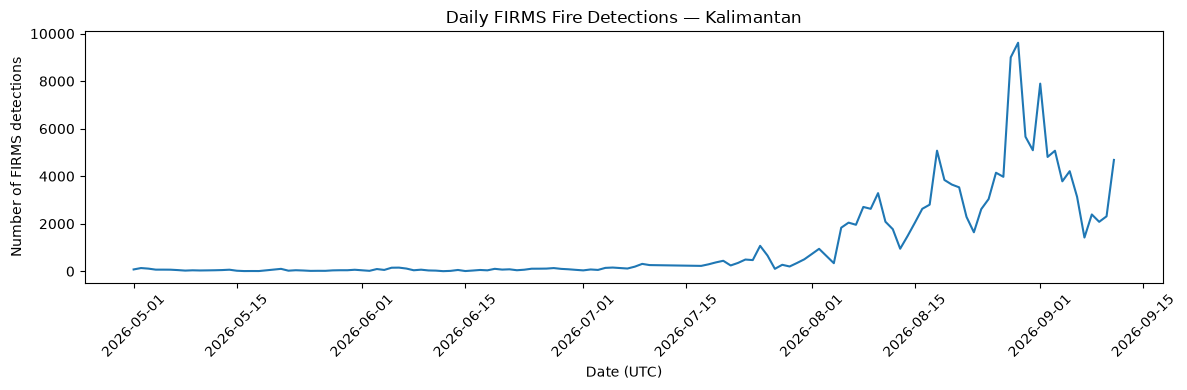

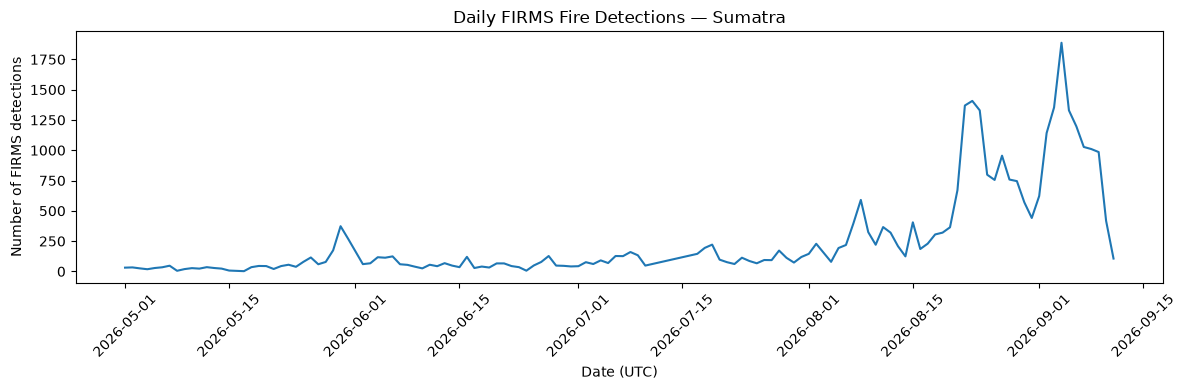

In [39]:
# 19. Plot daily detections

for region in regions:
    subset = daily_counts[daily_counts["region"] == region]

    if subset.empty:
        continue

    plt.figure(figsize=(12, 4))
    plt.plot(subset["date"], subset["n_detections"])
    plt.xlabel("Date (UTC)")
    plt.ylabel("Number of FIRMS detections")
    plt.title(f"Daily FIRMS Fire Detections — {region.title()}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


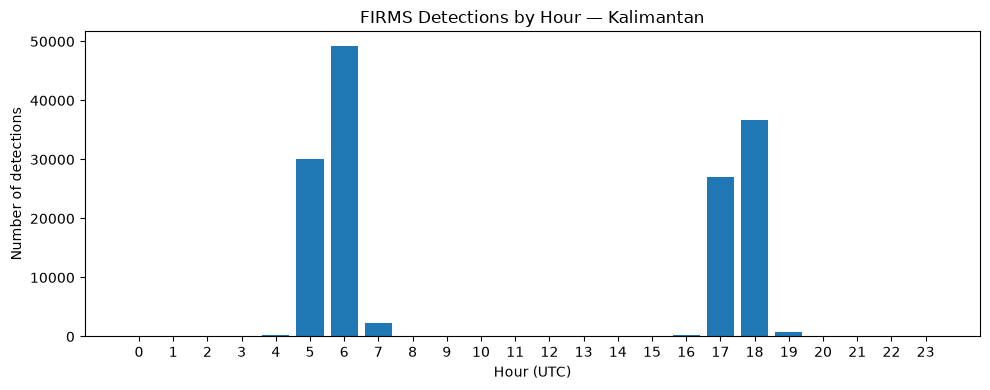

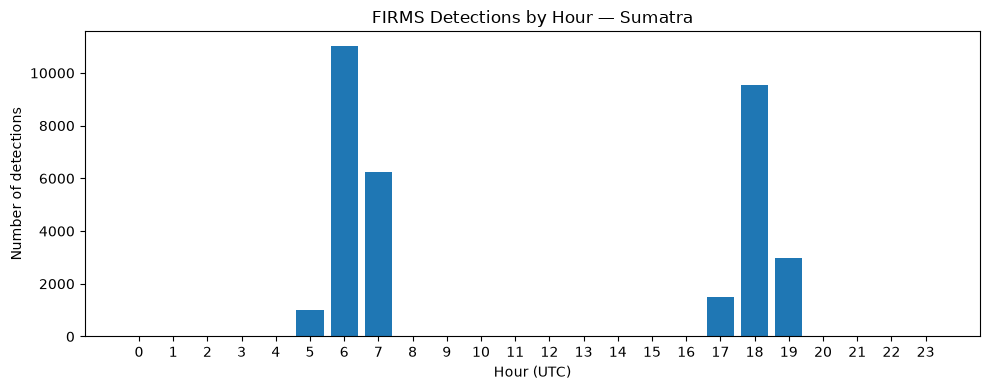

In [40]:
# 20. Hourly detection distribution

hourly_counts = (
    fire_all
    .groupby(["region", "hour_utc"])
    .size()
    .reset_index(name="n_detections")
)

# Make sure hour_utc is numeric
hourly_counts["hour_utc"] = pd.to_numeric(
    hourly_counts["hour_utc"],
    errors="coerce"
)

for region in regions:
    subset = (
        hourly_counts[hourly_counts["region"] == region]
        .set_index("hour_utc")["n_detections"]
        .reindex(range(24), fill_value=0)
    )

    plt.figure(figsize=(10, 4))
    plt.bar(subset.index, subset.values)
    plt.xlabel("Hour (UTC)")
    plt.ylabel("Number of detections")
    plt.title(f"FIRMS Detections by Hour — {region.title()}")
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()

## 8. Daily and regional summary

These summaries provide a compact audit record that can be reused in the thesis methodology/data-description section.


In [41]:
# 21. Regional summary

regional_summary = (
    fire_all.groupby("region")
    .agg(
        total_detections=("region", "size"),
        unique_dates=("date_utc", "nunique"),
        unique_source_files=("source_file", "nunique"),
        latitude_min=("lat", "min"),
        latitude_max=("lat", "max"),
        longitude_min=("lon", "min"),
        longitude_max=("lon", "max"),
        frp_mean=("frp", "mean"),
        frp_median=("frp", "median"),
        frp_max=("frp", "max"),
    )
    .reset_index()
)

regional_summary


,region,total_detections,unique_dates,unique_source_files,latitude_min,latitude_max,longitude_min,longitude_max,frp_mean,frp_median,frp_max
0,kalimantan,146314,126,126,-4.26212,7.38579,108.00037,119.49989,8.134530,4.52,569.39
1,sumatra,32297,125,125,-5.99616,5.97401,95.24544,106.49984,6.915649,4.04,332.85


In [42]:
# 22. Daily detection statistics

daily_statistics = (
    daily_counts.groupby("region")["n_detections"]
    .agg(
        mean_daily="mean",
        median_daily="median",
        min_daily="min",
        max_daily="max",
        std_daily="std",
    )
    .round(3)
    .reset_index()
)

daily_statistics


,region,mean_daily,median_daily,min_daily,max_daily,std_daily
0,kalimantan,1161.222,136.0,5,9616,1894.579
1,sumatra,258.376,93.0,2,1887,375.239


## 9. Audit flags

The final audit table converts the checks above into explicit pass/fail-style flags.

These flags are intended to make it easy to review the dataset before continuing to spatial binning.


In [43]:
# 23. Dataset-level audit flags

audit_flags = {
    "both_region_directories_exist": all(
        path.exists() for path in fire_dirs.values()
    ),
    "all_files_have_valid_filename_dates": (
        len(filename_audit) > 0 and
        filename_audit["has_valid_date"].all()
    ),
    "no_missing_dates_within_each_region_range": (
        coverage_df["missing_dates"].sum() == 0
    ),
    "no_duplicate_date_files": (
        coverage_df["duplicate_date_files"].sum() == 0
    ),
    "required_columns_present_in_all_files": (
        (file_quality_df["missing_required_columns"] == "").all()
        if not file_quality_df.empty else False
    ),
    "no_timestamp_parse_failures": (
        file_quality_df["timestamp_parse_failures"].fillna(0).sum() == 0
        if not file_quality_df.empty else False
    ),
    "no_missing_required_values": (
        combined_missing["missing_count"].sum() == 0
        if not fire_all.empty else False
    ),
    "no_invalid_coordinates": (
        invalid_lat == 0 and invalid_lon == 0
        if not fire_all.empty else False
    ),
    "no_negative_frp": (
        (fire_all["frp"] < 0).sum() == 0
        if not fire_all.empty else False
    ),
    "no_exact_duplicate_rows": (
        fire_all.duplicated().sum() == 0
        if not fire_all.empty else False
    ),
}

audit_flags_df = pd.DataFrame(
    [{"check": k, "pass": v} for k, v in audit_flags.items()]
)

audit_flags_df


,check,pass
0,both_region_directories_exist,True
1,all_files_have_valid_filename_dates,True
2,no_missing_dates_within_each_region_range,True
3,no_duplicate_date_files,True
4,required_columns_present_in_all_files,True
5,no_timestamp_parse_failures,True
6,no_missing_required_values,True
7,no_invalid_coordinates,True
8,no_negative_frp,True
9,no_exact_duplicate_rows,True


## 10. Save audit outputs

The raw FIRMS files are not modified.

Only audit summaries are written to `data/intermediate/`:

```text
data/intermediate/
├── audit_firms_file_inventory.csv
├── audit_firms_file_quality.csv
├── audit_firms_coverage.csv
├── audit_firms_regional_summary.csv
├── audit_firms_daily_counts.csv
└── audit_firms_flags.csv
```

These files make the audit reproducible without repeatedly reading every raw FIRMS CSV.


In [44]:
# 24. Save audit outputs

outputs = {
    "audit_firms_file_inventory.csv": inventory_df,
    "audit_firms_file_quality.csv": file_quality_df,
    "audit_firms_coverage.csv": coverage_df,
    "audit_firms_regional_summary.csv": regional_summary,
    "audit_firms_daily_counts.csv": daily_counts,
    "audit_firms_flags.csv": audit_flags_df,
}

for filename, df in outputs.items():
    path = intermediate_dir / filename
    df.to_csv(path, index=False)
    print("Saved:", path)


Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_file_inventory.csv
Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_file_quality.csv
Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_coverage.csv
Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_regional_summary.csv
Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_daily_counts.csv
Saved: c:\Users\Asus\Documents\skripsi-karhut\data\intermediate\audit_firms_flags.csv


## 11. Final audit conclusion

Before proceeding to spatial binning, verify that:

- the expected FIRMS files exist for the intended regions;
- filename dates are valid and their coverage is understood;
- required columns are available;
- timestamps can be parsed;
- missing values and invalid coordinates are understood;
- duplicate records are checked;
- empty files are documented rather than silently treated as missing dates;
- the overall date range matches the study period.

### Important methodological note

The audit establishes the quality and coverage of the **observed FIRMS detections**. It does not establish that a location without a FIRMS detection had no fire.

The next stage, `03_spatial_binning.ipynb`, converts point detections into grid-cell/day observations and constructs the complete cell-day panel used for the prediction task.
